In [1]:
import seaborn as sns

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np 

import h5py
from scipy.integrate import simpson
from scipy.optimize import curve_fit
from matplotlib.ticker import AutoMinorLocator

plt.rc('axes', linewidth=3, labelsize=22)
plt.rc('xtick', labelsize=22)  # fontsize of the x tick labels
plt.rc('ytick', labelsize=22)  # fontsize of the y tick labels
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'  # Axis labels
plt.rcParams['axes.titleweight'] = 'bold' 

sns.set_theme(font_scale=2.25)
sns.set_style("white")


In [2]:


def apply_ax_format(ax,xlabel="",ylabel="",title="",legend=False,inset=False):
    if not inset:
        ax.spines['bottom'].set_color('0')
        ax.spines['top'].set_color('1')
        ax.spines['right'].set_color('1')
        ax.spines['left'].set_color('0')
    ax.tick_params(which="both",direction='out', width=3, bottom=True, left=True)
    ax.grid(False)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.xaxis.set_minor_locator(AutoMinorLocator(4))
    ax.yaxis.set_minor_locator(AutoMinorLocator(4))
    if legend:
        plt.setp(ax.get_legend().get_texts(), fontsize='22') # for legend text
        plt.setp(ax.get_legend().get_title(), fontsize='22') # for legend title



In [3]:


# Fit the resolution data to a polynomial for extrapolation
def poly_func(x, a, b, c):
    return a * x**2 + b * x + c

# Create a function to get resolution for any energy
def get_resolution(e,popt):
    return np.maximum(poly_func(e, *popt), 1e-10)  # Ensure non-zero resolution


# Perform Gaussian broadening using convolution with energy-dependent widths
def gaussian_broadening(dos, energy, sigmas):
    broadened_dos = np.zeros_like(dos)
    for i in range(len(energy)):
        # Create a Gaussian kernel centered at each energy point with width sigmas[i]
        kernel = np.exp(-0.5 * ((energy - energy[i]) / sigmas[i])**2)
        kernel /= simpson(kernel, energy)  # Normalize the kernel to preserve area
        broadened_dos += dos[i] * kernel  # Convolve DOS with Gaussian kernel
    return broadened_dos

def apply_gaussian_broadening(dos_data,metric='dos total (nm2/ps)',unit_cell_atoms=1):
    energy = dos_data['Energy Transfer (meV)'].values
    dos = dos_data[metric].values

    resolution_data = pd.read_csv('../data/resolution.csv')
    res_energy = resolution_data['Energy (meV)'].values
    resolution = resolution_data['Resolution'].values
    popt, _ = curve_fit(poly_func, res_energy, resolution)
    
    # Create an array of sigmas for Gaussian broadening based on the resolution function
    sigmas = get_resolution(energy,popt) / np.sqrt(8 * np.log(2))  # Convert FWHM to sigma


    broadened_dos = gaussian_broadening(dos, energy, sigmas)

    # Area normalize both original and broadened DOS
    original_area = simpson(dos, energy)
    broadened_area = simpson(broadened_dos, energy)

    dos_normalized = dos / original_area
    #dos_normalized-=dos_normalized[0]
    broadened_dos_normalized = broadened_dos / broadened_area
    return dos_normalized #3*unit_cell_atoms*broadened_dos_normalized

In [4]:
results_directory=dict()
for temperature in np.arange(100,450,50):
    for subset in ["H2O","SiO2","Total"]:
        results_directory["../results/gromacs/pore/4nm/H2O/results_720/%d/%s/out_dos.h5" % (temperature,subset)]=(temperature,subset)

df_list=list()

min_energy=0
max_energy=1500

for pdos_file,(temperature,subset) in results_directory.items():
    print(pdos_file)
    h5file=h5py.File(pdos_file)
    data_dict=dict()
    omega_shape=h5file["omega"][:].shape
    for k in h5file.keys():
        data_array=h5file[k][:]
        if data_array.shape != omega_shape or "_0" in k:
            continue
        units=h5file[k].attrs['units']
        data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
    h5file.close()
    df_tmp=pd.DataFrame(data_dict).query("%f < `omega (rad/ps)` and `omega (rad/ps)` < %f"%(min_energy/0.6582,max_energy/0.6582))
    df_tmp["Energy Transfer (meV)"]=df_tmp["omega (rad/ps)"]*0.6582
    df_tmp["Normalized Count"]=apply_gaussian_broadening(df_tmp)
    df_tmp["Max Normalized Count"]=df_tmp["Normalized Count"]/df_tmp["Normalized Count"].max()
    df_tmp["Temperature (K)"]=temperature
    df_tmp["Subset"]=subset
    df_list.append(df_tmp)
        
df_dos_mdanse=pd.concat(df_list,ignore_index=True)
df_dos_mdanse

../results/gromacs/pore/4nm/H2O/results_720/100/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/100/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/100/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/150/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/150/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/150/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/200/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/200/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/200/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/250/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/250/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/250/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/300/H2O/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/300/SiO2/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_720/300/Total/out_dos.h5
../results/gromacs/pore/4nm/H2O/results_

,dos H (nm2/ps),dos M (nm2/ps),dos O (nm2/ps),dos total (nm2/ps),omega (rad/ps),omega window (au),time window (au),Energy Transfer (meV),Normalized Count,Max Normalized Count,Temperature (K),Subset,dos Si (nm2/ps)
0,0.000014,0.000010,1.033359e-05,0.000014,0.062835,2.501685,9.999875e-01,0.041358,0.000074,0.003310,100,H2O,NaN
1,0.000014,0.000011,1.044359e-05,0.000014,0.125670,2.486913,9.999500e-01,0.082716,0.000074,0.003343,100,H2O,NaN
2,0.000014,0.000011,1.062712e-05,0.000014,0.188505,2.462486,9.998875e-01,0.124074,0.000076,0.003397,100,H2O,NaN
3,0.000014,0.000011,1.088446e-05,0.000014,0.251340,2.428692,9.998000e-01,0.165432,0.000077,0.003474,100,H2O,NaN
4,0.000015,0.000011,1.121602e-05,0.000015,0.314175,2.385922,9.996875e-01,0.206790,0.000080,0.003572,100,H2O,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
209974,0.000022,NaN,2.523867e-08,0.000021,628.035787,0.000000,3.716009e-17,413.373155,0.000033,0.001578,400,Total,6.103163e-08
209975,0.000022,NaN,2.524778e-08,0.000021,628.098622,0.000000,2.741944e-18,413.414513,0.000033,0.001578,400,Total,6.105807e-08
209976,0.000022,NaN,2.525467e-08,0.000021,628.161457,0.000000,4.071618e-17,413.455871,0.000033,0.001579,400,Total,6.107806e-08
209977,0.000022,NaN,2.525930e-08,0.000021,628.224292,0.000000,8.530829e-18,413.497229,0.000033,0.001579,400,Total,6.109147e-08


In [5]:
results_directory=dict()
for temperature in np.arange(100,450,50):
    for subset in ["H2O","SiO2","Total"]:
        results_directory["../results/gromacs/pore/4nm/H2O/results_720/%d/%s/out_msd.h5" % (temperature,subset)]=(temperature,subset)

df_list=list()

min_energy=0
max_energy=1500

for rmsd_file,(temperature,subset) in results_directory.items():
    print(rmsd_file)
    h5file=h5py.File(rmsd_file)
    data_dict=dict()
    omega_shape=h5file["time"][:].shape
    for k in h5file.keys():
        data_array=h5file[k][:]
        if data_array.shape != omega_shape or "_0" in k:
            continue
        units=h5file[k].attrs['units']
        data_dict["%s (%s)"%(k.replace("_"," "),units)]=data_array
    h5file.close()
    df_tmp=pd.DataFrame(data_dict)
    df_tmp["Temperature (K)"]=temperature
    df_tmp["Subset"]=subset
    df_list.append(df_tmp)
        
df_rmsd_mdanse=pd.concat(df_list,ignore_index=True)
df_rmsd_mdanse

../results/gromacs/pore/4nm/H2O/results_720/100/H2O/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/100/SiO2/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/100/Total/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/150/H2O/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/150/SiO2/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/150/Total/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/200/H2O/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/200/SiO2/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/200/Total/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/250/H2O/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/250/SiO2/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/250/Total/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/300/H2O/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/300/SiO2/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_720/300/Total/out_msd.h5
../results/gromacs/pore/4nm/H2O/results_

,msd H (nm2),msd M (nm2),msd O (nm2),msd total (nm2),time (ps),Temperature (K),Subset,msd Si (nm2)
0,1.035641e-13,1.019086e-13,1.013880e-13,1.035606e-13,0.000000,100,H2O,NaN
1,3.987253e-05,3.879053e-06,3.661205e-06,3.981545e-05,0.005000,100,H2O,NaN
2,1.349676e-04,1.500540e-05,1.436386e-05,1.347775e-04,0.010000,100,H2O,NaN
3,2.471990e-04,3.247329e-05,3.157537e-05,2.468591e-04,0.015000,100,H2O,NaN
4,3.642334e-04,5.569437e-05,5.485843e-05,3.637458e-04,0.020000,100,H2O,NaN
...,...,...,...,...,...,...,...,...
209995,3.165079e+00,NaN,3.771921e-01,3.091350e+00,49.974999,400,Total,0.705400
209996,3.165211e+00,NaN,3.772021e-01,3.091479e+00,49.979999,400,Total,0.705422
209997,3.165266e+00,NaN,3.772129e-01,3.091533e+00,49.984999,400,Total,0.705440
209998,3.165434e+00,NaN,3.772225e-01,3.091697e+00,49.989999,400,Total,0.705461


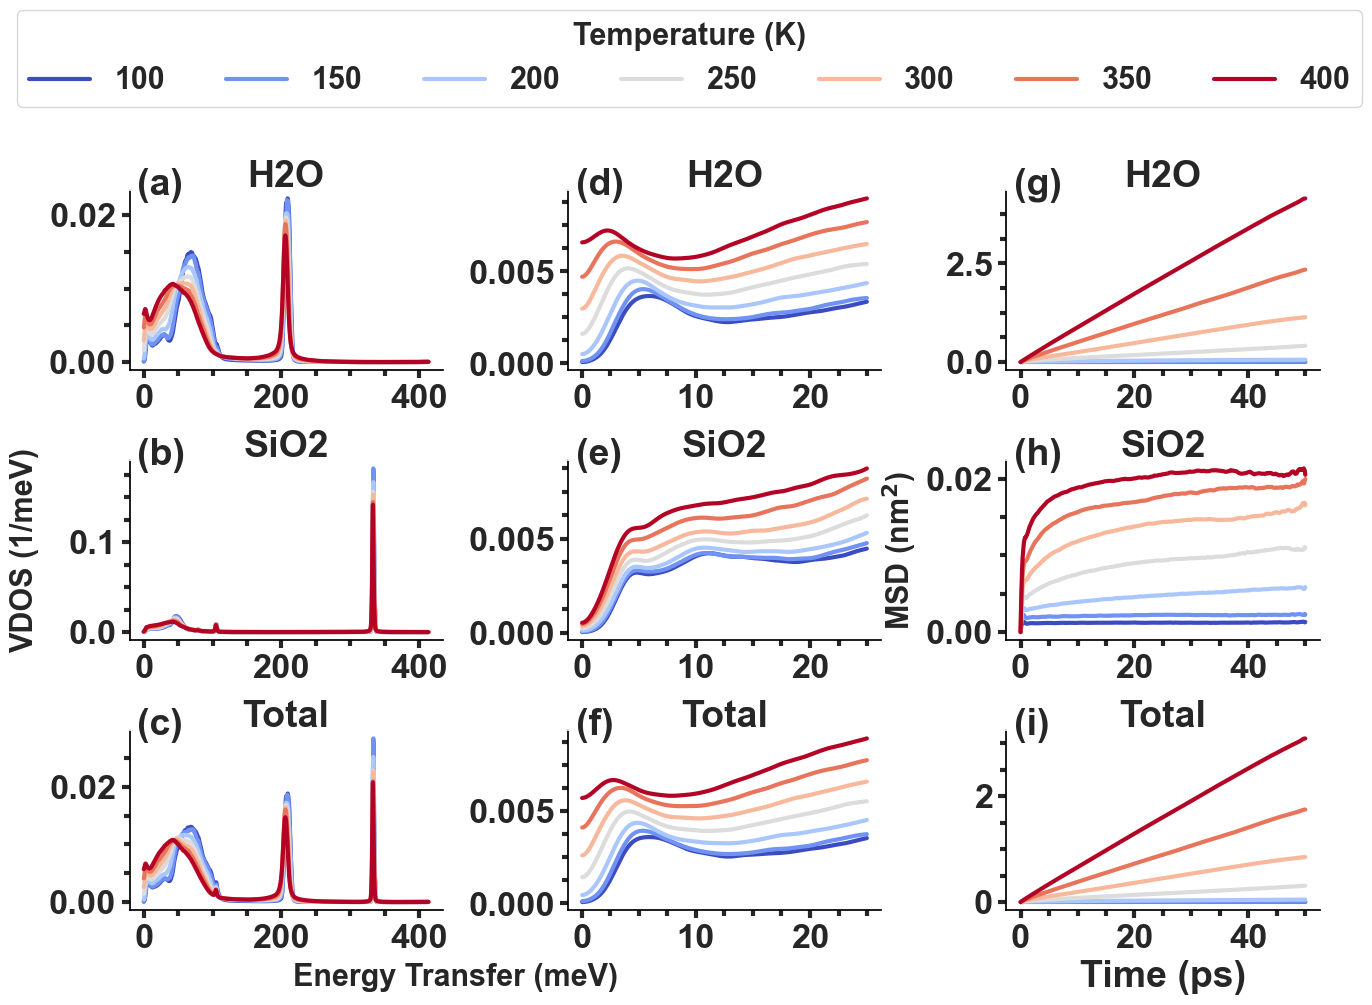

In [6]:
subset_list=df_dos_mdanse["Subset"].unique()

fig, axs = plt.subplots(ncols=3,nrows=len(subset_list),figsize=(7*2,3*len(subset_list)))
palette=sns.color_palette("tab10")

labx=0.025
laby=0.975
index=["(%s)"%x for x in list("abcdefghijkl")]

for i, subset in enumerate(subset_list):
    ax=axs[i,0]

    df_tmp=df_dos_mdanse.query("Subset == '%s' " % subset)
    ax.text(labx, laby, index[i],weight='bold' ,transform=ax.transAxes)

    sns.lineplot(data=df_tmp
                ,y="Normalized Count"
                ,x="Energy Transfer (meV)"
                ,ax=ax
                ,hue="Temperature (K)"
                 ,palette="coolwarm"
                ,legend=i==0
                 ,lw=3
           )

    apply_ax_format(ax,legend=i==0)
   
    ax.set_title("%s" % subset, y=0.975)
    if i ==0:
        sns.move_legend(ax,'lower center',bbox_to_anchor=(0.5,0.975),ncol=7,bbox_transform=fig.transFigure,fontsize=22,title_fontsize=22)

    ax=axs[i,1]

    df_tmp=df_dos_mdanse.query("Subset == '%s' and `Energy Transfer (meV)` < 25" % subset)
    ax.text(labx, laby, index[i+len(subset_list)],weight='bold' ,transform=ax.transAxes)

    sns.lineplot(data=df_tmp
                ,y="Normalized Count"
                ,x="Energy Transfer (meV)"
                ,ax=ax
                ,hue="Temperature (K)"
                 ,palette="coolwarm"
                ,legend=False
                 ,lw=3
           )

    apply_ax_format(ax)
   
    ax.set_title("%s" % subset, y=0.975)

    ax=axs[i,2]

    df_tmp=df_rmsd_mdanse.query("Subset == '%s' " % subset)

    ax.text(labx, laby, index[i+2*len(subset_list)],weight='bold' ,transform=ax.transAxes)

    sns.lineplot(data=df_tmp
                ,y="msd total (nm2)"
                ,x="time (ps)"
                ,ax=ax
                ,hue="Temperature (K)"
                 ,palette="coolwarm"
                ,legend=False
                 ,lw=3
           )
    #ax.set_ylim(0,df_rmsd_mdanse["msd total (nm2)"].max())
    apply_ax_format(ax,xlabel="" if subset != "Total" else "Time (ps)")
    
    ax.set_title("%s" % subset, y=0.975)

ax.text(0.025, 0.5, "VDOS (1/meV)",weight='bold' ,transform=fig.transFigure,ha='center',va='center',fontsize=22,rotation='vertical')         
ax.text(0.65, 0.5, "MSD (nm$^2$)",weight='bold' ,transform=fig.transFigure,ha='center',va='center',fontsize=22,rotation='vertical')
ax.text(0.333, 0.025, "Energy Transfer (meV)",weight='bold' ,transform=fig.transFigure,ha='center',va='center',fontsize=22)         

            
# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.4, 
                    hspace=0.5
                   )

plt.savefig("../figures/fig10.pdf", pad_inches=0.2,bbox_inches="tight")

In [40]:
temperature=[273.15,274.15,277.15,277.15,278.15,283.15,283.15,288.15,288.15,288.15,293.15,293.15,293.15,298.15,298.15,298.15,298.15,298.15,303.15,303.15,303.15,308.15,308.15,313.15,313.15,318.15,318.15,318.15,323.15,323.15,329.15,333.15,333.15,343.15,353.15,363.15,373.15]
D_exp=[1.13,1.149,1.27,1.276,1.313,1.536,1.55,1.756,1.766,1.777,2.022,2.023,2.025,2.296,2.299,2.299,2.3,2.317,2.59,2.597,2.616,2.895,2.919,3.222,3.24,3.55,3.575,3.601,3.968,3.983,4.444,4.7,4.772,5.646,6.582,7.578,8.623]

df_D_exp=pd.DataFrame({"Temperature (K)":temperature,"D ($\mu m^2/ms$)":D_exp}).groupby("Temperature (K)").mean().reset_index()

from scipy.interpolate import CubicSpline
cs = CubicSpline(df_D_exp["Temperature (K)"],df_D_exp["D ($\mu m^2/ms$)"])

def line(x,m,x0):
    return m*x+x0
def get_diff_coeff(x):
    df_tmp=x.query("`time (ps)` > 5")
    ydata=df_tmp["msd total (nm2)"]
    xdata=df_tmp["time (ps)"]
    popt, pcov = curve_fit(line, xdata, ydata,p0=[1,0],method='lm')
    return pd.Series({"D ($\mu m^2/ms$)":"%.2f"%np.round(1e3*popt[0]/6,2)})

def get_exp_coeff(x):
    indx=x > df_D_exp["Temperature (K)"].min()
    result=np.zeros_like(x,dtype=float)
    result[indx] = cs(x[indx].values)
    print(cs(x))
    return ["%.2f"%x for x in result]

df_diff=df_rmsd_mdanse.groupby(["Temperature (K)","Subset"]).apply(get_diff_coeff,include_groups=False).unstack()
df_diff[('D ($\mu m^2/ms$)','Experimental')]=get_exp_coeff(df_diff.index)

print(df_diff.to_latex())

[7.39779910e+03 2.71590450e+03 5.96535890e+02 2.43603760e+01
 2.41114204e+00 6.28566077e+00 1.12560936e+01]
\begin{tabular}{lllll}
\toprule
 & \multicolumn{4}{r}{D ($\mu m^2/ms$)} \\
Subset & H2O & SiO2 & Total & Experimental \\
Temperature (K) &  &  &  &  \\
\midrule
100 & 0.00 & 0.00 & 0.00 & 0.00 \\
150 & 0.01 & 0.00 & 0.01 & 0.00 \\
200 & 0.16 & 0.01 & 0.12 & 0.00 \\
250 & 1.25 & 0.01 & 0.94 & 0.00 \\
300 & 3.80 & 0.02 & 2.83 & 2.41 \\
350 & 7.68 & 0.02 & 5.72 & 6.29 \\
400 & 13.81 & 0.01 & 10.28 & 11.26 \\
\bottomrule
\end{tabular}



In [18]:
df_diff["Temperature (C)"]=df_diff.index-273.15
df_diff[('D ($\mu m^2/ms$)',   'H2O')]=df_diff[('D ($nm^2/ps$)',   'H2O')].map(lambda x : x*1e3)
df_diff

D ($nm^2/ps$)                         Temperature (C)  \
Subset                    H2O          SiO2     Total                   
Temperature (K)                                                         
100                  0.000002  2.515054e-07  0.000001         -173.15   
150                  0.000008  7.626229e-07  0.000007         -123.15   
200                  0.000157  8.170745e-06  0.000119          -73.15   
250                  0.001254  1.481611e-05  0.000937          -23.15   
300                  0.003801  1.768818e-05  0.002833           26.85   
350                  0.007680  1.684410e-05  0.005719           76.85   
400                  0.013806  9.846505e-06  0.010276          126.85   

                D ($\mum^2/ms$) D ($\mu m^2/ms$)  
Subset                      H2O              H2O  
Temperature (K)                                   
100                    0.000003         0.001620  
150                    0.000017         0.008485  
200                    0.000314         0.157133  
250                    0.002508         1.254062  
300                    0.007603         3.801440  
350                    0.015359         7.679641  
400                    0.027611        13.805697

Index([-173.14999999999998, -123.14999999999998,  -73.14999999999998,
       -23.149999999999977,  26.850000000000023,   76.85000000000002,
        126.85000000000002],
      dtype='float64', name='Temperature (K)')

In [8]:
""
results_directory=dict()
for temperature in np.arange(100,300,50):
    for subset in ["H2O","SiO2","Total"]:
        results_directory["../results/gromacs/pore/4nm/H2O/results_720/%d/%s/dos.csv" % (temperature,subset)]=(temperature,subset)

df_list=list()
for pdos_file,(temperature,subset) in results_directory.items():
    df_tmp=pd.read_csv(pdos_file,names=['Wave number $(cm^{-1})',"dos","dos(solid)","dos(diff)"],skiprows=1)
    df_tmp["Temperature (K)"]=temperature
    df_tmp["Subset"]=subset
    df_tmp['Energy Transfer (meV)']=df_tmp['Wave number $(cm^{-1})']*0.124
    dos=df_tmp["dos(solid)"].values
    energy=df_tmp["Energy Transfer (meV)"].values
    original_area = simpson(dos, energy)
    df_tmp["VDOS (1/meV)"] = df_tmp["dos(solid)"]/original_area
    df_list.append(df_tmp)

df_dos_gmx=pd.concat(df_list,ignore_index=True)
df_dos_gmx

,Wave number $(cm^{-1}),dos,dos(solid),dos(diff),Temperature (K),Subset,Energy Transfer (meV),VDOS (1/meV)
0,0.00000,1.57570,0.000000,1.575700,100,H2O,0.000000,0.000000
1,1.33426,1.61096,0.035337,1.575630,100,H2O,0.165448,0.000030
2,2.66851,1.69155,0.116155,1.575400,100,H2O,0.330895,0.000098
3,4.00277,1.68574,0.110719,1.575020,100,H2O,0.496343,0.000093
4,5.33703,1.72219,0.147701,1.574490,100,H2O,0.661792,0.000125
...,...,...,...,...,...,...,...,...
29995,3328.97000,11.46560,11.425500,0.040103,250,Total,412.792280,0.001269
29996,3330.30000,11.46540,11.425300,0.040071,250,Total,412.957200,0.001269
29997,3331.64000,11.46550,11.425400,0.040039,250,Total,413.123360,0.001269
29998,3332.97000,11.46590,11.425900,0.040007,250,Total,413.288280,0.001269


In [9]:
results_directory=dict()
for temperature in np.arange(100,300,50):
    for subset in ["H2O","SiO2","Total"]:
        results_directory["../results/gromacs/pore/4nm/H2O/results_720/%d/%s/rmsd.csv" % (temperature,subset)]=(temperature,subset)

df_list=list()
for pdos_file,(temperature,subset) in results_directory.items():
    df_tmp=pd.read_csv(pdos_file,names=['Time (ns)',"RMSD (nm)"],skiprows=1)
    df_tmp["Temperature (K)"]=temperature
    df_tmp["Subset"]=subset
    df_list.append(df_tmp)

df_rmsd_gmx=pd.concat(df_list,ignore_index=True)
df_rmsd_gmx

,Time (ns),RMSD (nm),Temperature (K),Subset
0,0.000000,0.000000,100,H2O
1,0.000005,0.002742,100,H2O
2,0.000010,0.005215,100,H2O
3,0.000015,0.007366,100,H2O
4,0.000020,0.009337,100,H2O
...,...,...,...,...
120007,0.049980,0.403260,250,Total
120008,0.049985,0.403284,250,Total
120009,0.049990,0.403307,250,Total
120010,0.049995,0.403329,250,Total


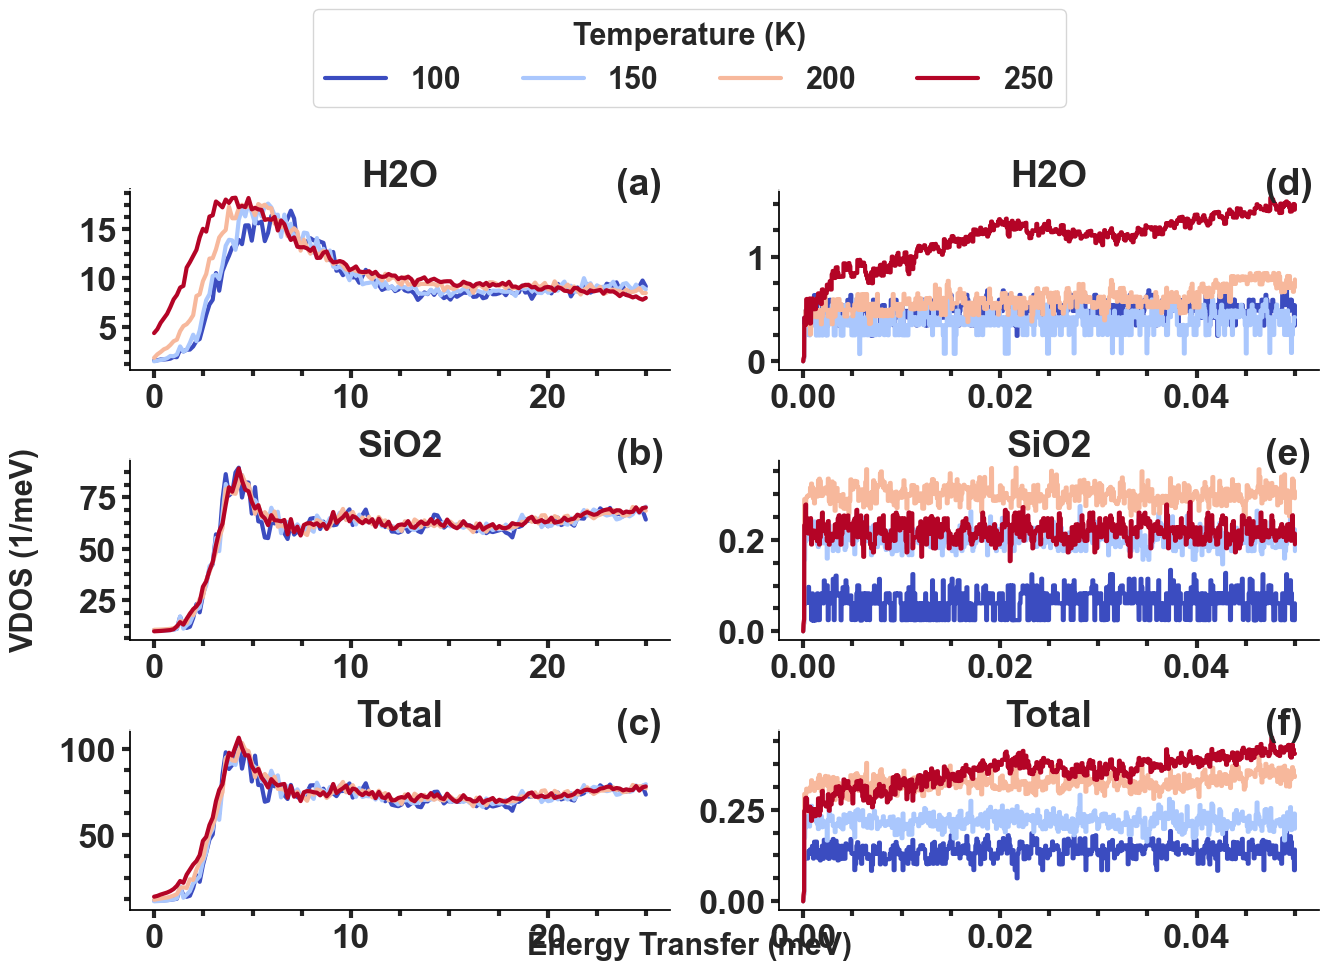

In [10]:
subset_list=df_dos_gmx["Subset"].unique()

fig, axs = plt.subplots(ncols=2,nrows=len(subset_list),figsize=(7*2,3*len(subset_list)))
palette=sns.color_palette("tab10")

labx=0.9
laby=0.975
index=["(%s)"%x for x in list("abcdefghijkl")]

for i, subset in enumerate(subset_list):
    ax=axs[i,0]

    df_tmp=df_dos_gmx.query("Subset == '%s'  and `Energy Transfer (meV)` < 25" % subset)
    ax.text(labx, laby, index[i],weight='bold' ,transform=ax.transAxes)

    sns.lineplot(data=df_tmp
                ,y="dos"
                ,x="Energy Transfer (meV)"
                ,ax=ax
                ,hue="Temperature (K)"
                ,legend=i==0
                 ,palette="coolwarm"
                 ,lw=3
           )

    apply_ax_format(ax,legend=i==0)
   
    ax.set_title("%s" % subset, y=0.975)
    if i ==0:
        sns.move_legend(ax,'lower center',bbox_to_anchor=(0.5,0.975),ncol=7,bbox_transform=fig.transFigure,fontsize=22,title_fontsize=22)


    ax=axs[i,1]

    df_tmp=df_rmsd_gmx.query("Subset == '%s'  " % subset)

    ax.text(labx, laby, index[i+len(subset_list)],weight='bold' ,transform=ax.transAxes)

    sns.lineplot(data=df_tmp
                ,y="RMSD (nm)"
                ,x="Time (ns)"
                ,ax=ax
                ,hue="Temperature (K)"
                 ,palette="coolwarm"
                ,legend=False
                 ,lw=3
           )
    
    apply_ax_format(ax)
    
    ax.set_title("%s" % subset, y=0.975)

ax.text(0.025, 0.5, "VDOS (1/meV)",weight='bold' ,transform=fig.transFigure,ha='center',va='center',fontsize=22,rotation='vertical')         
ax.text(0.5, 0.06, "Energy Transfer (meV)",weight='bold' ,transform=fig.transFigure,ha='center',va='center',fontsize=22)         

            
# set the spacing between subplots
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.95, 
                    top=0.9, 
                    wspace=0.2, 
                    hspace=0.5
                   )